<a href="https://colab.research.google.com/github/AlexMoffatt10/PDA4052-EDA-Sales-analysis/blob/main/Programming_For_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install openpyxl --quiet
print('Libraries ready')

Libraries ready


In [26]:
from google.colab import files
uploaded = files.upload()
FILENAME = list(uploaded.keys())[0]
print(f'File uploaded: {FILENAME}')

Saving Sales Data_PDA_4052.xlsx to Sales Data_PDA_4052 (2).xlsx
File uploaded: Sales Data_PDA_4052 (2).xlsx


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'font.family':'sans-serif',
    'axes.spines.top':False,'axes.spines.right':False})
PALETTE = {'Kelly':'#7B2D8B','Peter':'#E8873A','Pryia':'#2A9D8F'}
print('All libraries imported successfully')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')

All libraries imported successfully
pandas  2.2.2
numpy   2.0.2


In [28]:
df = pd.read_excel(FILENAME, header=1)

print(' DATASET SHAPE ')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')


df['order_id']     = df['order_id'].astype(str)
df['customer_id']  = df['customer_id'].astype(str)
df['sales_person'] = df['sales_person'].astype(str)
df['priority']     = df['priority'].astype(str)
df['ship_mode']    = df['ship_mode'].astype(str)
df['date']         = pd.to_datetime(df['date'])
df['value_£']      = pd.to_numeric(df['value_£'], errors='coerce')

print('\n CORRECTED DATA TYPES ')
print(df.dtypes)

print('\n MISSING VALUES ')
print(df.isnull().sum())

print('\n DUPLICATE CHECK ')
print(f'Fully duplicated rows:             {df.duplicated().sum()}')
print(f'Duplicate order_ids (multi-party): {df.duplicated(subset=["order_id"]).sum()}')

print('\n SAMPLE DUPLICATE ORDER_IDs (legitimacy check) ')
df_dup = df[df.duplicated(subset=['order_id'], keep=False)]
print(df_dup.sort_values('order_id')[['order_id','sales_person','value_£']].head(6).to_string())
print('\nSame order_id -> different sales_persons = legitimate multi-party records')

 DATASET SHAPE 
Rows: 1001, Columns: 7

 CORRECTED DATA TYPES 
order_id                object
customer_id             object
sales_person            object
priority                object
ship_mode               object
date            datetime64[ns]
value_£                float64
dtype: object

 MISSING VALUES 
order_id        0
customer_id     0
sales_person    0
priority        0
ship_mode       0
date            0
value_£         0
dtype: int64

 DUPLICATE CHECK 
Fully duplicated rows:             0
Duplicate order_ids (multi-party): 356

 SAMPLE DUPLICATE ORDER_IDs (legitimacy check) 
    order_id sales_person  value_£
831    10052        Pryia    90.47
161    10052        Kelly   151.47
160    10052        Kelly   512.62
167    10629        Kelly    82.56
516    10629        Peter   306.84
817    10658        Pryia  1484.97

Same order_id -> different sales_persons = legitimate multi-party records


In [29]:
print(' DESCRIPTIVE STATISTICS: value_£ ')
print(df['value_£'].describe().round(2))

print('\n TRANSACTIONS PER SALES PERSON ')
print(df['sales_person'].value_counts())

print('\n PRIORITY LEVEL COUNTS ')
print(df['priority'].value_counts())

print('\n DATE RANGE ')
print(f'From: {df["date"].min().date()}  to  {df["date"].max().date()}')

print('\n SHAPIRO-WILK NORMALITY TEST (n=500 sample) ')
stat_sw, p_sw = stats.shapiro(df['value_£'].sample(500, random_state=42))
print(f'W statistic : {stat_sw:.4f}')
print(f'p-value     : {p_sw:.6f}')
if p_sw < 0.05:
    print('Result      : NON-NORMAL (p < 0.05)')
    print('Action      : Use non-parametric tests throughout')

 DESCRIPTIVE STATISTICS: value_£ 
count     1001.00
mean      1778.40
std       3457.46
min          2.45
25%        134.40
50%        417.58
75%       1816.93
max      27448.24
Name: value_£, dtype: float64

 TRANSACTIONS PER SALES PERSON 
sales_person
Peter    344
Pryia    338
Kelly    319
Name: count, dtype: int64

 PRIORITY LEVEL COUNTS 
priority
Critical         221
Not Specified    213
Low              200
High             196
Medium           171
Name: count, dtype: int64

 DATE RANGE 
From: 2020-06-12  to  2020-11-30

 SHAPIRO-WILK NORMALITY TEST (n=500 sample) 
W statistic : 0.4971
p-value     : 0.000000
Result      : NON-NORMAL (p < 0.05)
Action      : Use non-parametric tests throughout


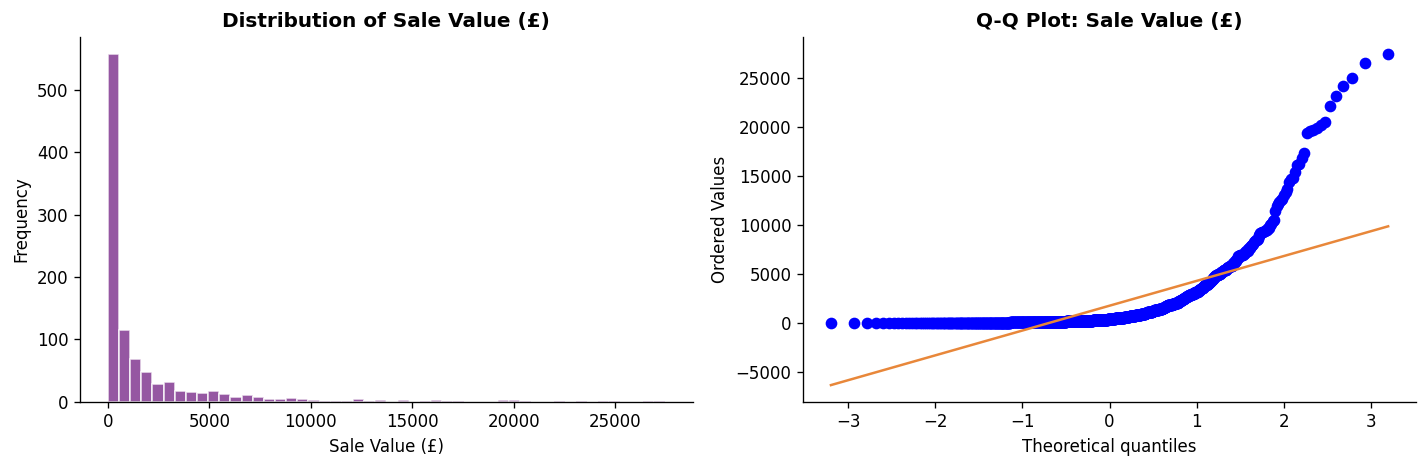

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['value_£'], bins=50, color='#7B2D8B', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Sale Value (£)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sale Value (£)'); axes[0].set_ylabel('Frequency')
stats.probplot(df['value_£'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Sale Value (£)', fontsize=12, fontweight='bold')
axes[1].get_lines()[1].set_color('#E8873A')
plt.tight_layout()
plt.show();

In [31]:
df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean.dropna(subset=['value_£'])
print(f'3a. dropna:          {before} -> {len(df_clean)} rows (removed: {before-len(df_clean)})')

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'3b. drop_duplicates: {before} -> {len(df_clean)} rows (removed: {before-len(df_clean)})')

priority_map = {'Low':1,'Medium':2,'High':3,'Critical':4}
df_clean['priority_num'] = df_clean['priority'].map(priority_map)
print(f'3c. priority_num:    Low=1 to Critical=4 encoded via map()')
print(f'                     NaN count: {df_clean["priority_num"].isna().sum()} (Not Specified)')

df_clean['month']       = df_clean['date'].dt.to_period('M')
df_clean['month_label'] = df_clean['date'].dt.strftime('%b %Y')
df_clean['day_of_week'] = df_clean['date'].dt.day_name()
print(f'3d. temporal:        month, month_label, day_of_week added via dt accessor')

Q1 = df_clean['value_£'].quantile(0.25)
Q3 = df_clean['value_£'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR
df_clean['outlier_flag'] = df_clean['value_£'] > upper_fence
n_out = df_clean['outlier_flag'].sum()
print(f'3e. IQR fences:      lower=£{lower_fence:.2f}, upper=£{upper_fence:.2f}')
print(f'    outlier_flag:    {n_out} flagged ({100*n_out/len(df_clean):.1f}%) — retained not removed')

df_clean['log_value'] = np.log1p(df_clean['value_£'])
print(f'3f. log_value:       np.log1p(value_£) applied — compresses right skew')
print(f'\nPre-processing complete. Final shape: {df_clean.shape}')

3a. dropna:          1001 -> 1001 rows (removed: 0)
3b. drop_duplicates: 1001 -> 1001 rows (removed: 0)
3c. priority_num:    Low=1 to Critical=4 encoded via map()
                     NaN count: 213 (Not Specified)
3d. temporal:        month, month_label, day_of_week added via dt accessor
3e. IQR fences:      lower=£-2389.39, upper=£4340.73
    outlier_flag:    122 flagged (12.2%) — retained not removed
3f. log_value:       np.log1p(value_£) applied — compresses right skew

Pre-processing complete. Final shape: (1001, 13)


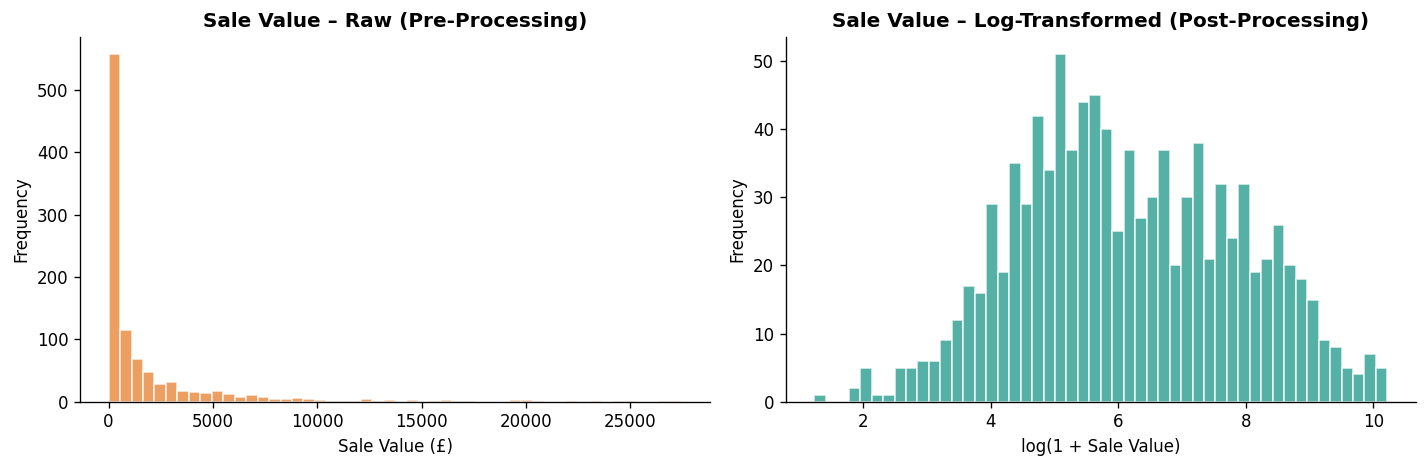

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['value_£'], bins=50, color='#E8873A', edgecolor='white', alpha=0.8)
axes[0].set_title('Sale Value – Raw (Pre-Processing)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sale Value (£)'); axes[0].set_ylabel('Frequency')
axes[1].hist(df_clean['log_value'], bins=50, color='#2A9D8F', edgecolor='white', alpha=0.8)
axes[1].set_title('Sale Value – Log-Transformed (Post-Processing)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Sale Value)'); axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show();

In [33]:
print(' SALES PERSON PERFORMANCE (groupby) ')
sp_stats = df_clean.groupby('sales_person')['value_£'].agg(
    Transactions='count', Total_Revenue='sum',
    Mean_Value='mean', Median_Value='median', Std_Dev='std'
).round(2)
print(sp_stats)

print('\n MONTHLY REVENUE BREAKDOWN (groupby + unstack) ')
monthly = df_clean.groupby(['month','sales_person'])['value_£'].sum().unstack()
print(monthly.round(2))

kelly = df_clean[df_clean['sales_person']=='Kelly']['value_£']
peter = df_clean[df_clean['sales_person']=='Peter']['value_£']
pryia = df_clean[df_clean['sales_person']=='Pryia']['value_£']

print('\n KRUSKAL-WALLIS TEST (non-parametric ANOVA equivalent) ')
H, p_kw = stats.kruskal(kelly, peter, pryia)
print(f'H statistic : {H:.4f}')
print(f'p-value     : {p_kw:.4f}')
print(f'Significant : {"YES" if p_kw < 0.05 else "NO"} (alpha = 0.05)')

print('\n PAIRWISE MANN-WHITNEY U TESTS ')
for a, b, na, nb in [(kelly,peter,'Kelly','Peter'),(kelly,pryia,'Kelly','Pryia'),(peter,pryia,'Peter','Pryia')]:
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f'{na:6s} vs {nb:6s}:  U={u:>8.0f},  p={p:.4f}  ->  {"SIGNIFICANT" if p<0.05 else "not significant"}')

 SALES PERSON PERFORMANCE (groupby) 
              Transactions  Total_Revenue  Mean_Value  Median_Value  Std_Dev
sales_person                                                                
Kelly                  319      558659.62     1751.28        366.84  3231.78
Peter                  344      549292.06     1596.78        338.20  3391.70
Pryia                  338      672228.97     1988.84        520.02  3718.74

 MONTHLY REVENUE BREAKDOWN (groupby + unstack) 
sales_person      Kelly      Peter      Pryia
month                                        
2020-06        55052.67   26779.29   62447.76
2020-07       104374.60  140824.43  132944.58
2020-08       109806.12  106488.33  116351.04
2020-09       112121.18   88444.06  124025.75
2020-10       108327.39  109380.93  137470.14
2020-11        68977.66   77375.02   98989.70

 KRUSKAL-WALLIS TEST (non-parametric ANOVA equivalent) 
H statistic : 6.0269
p-value     : 0.0491
Significant : YES (alpha = 0.05)

 PAIRWISE MANN-WHITNEY U TES

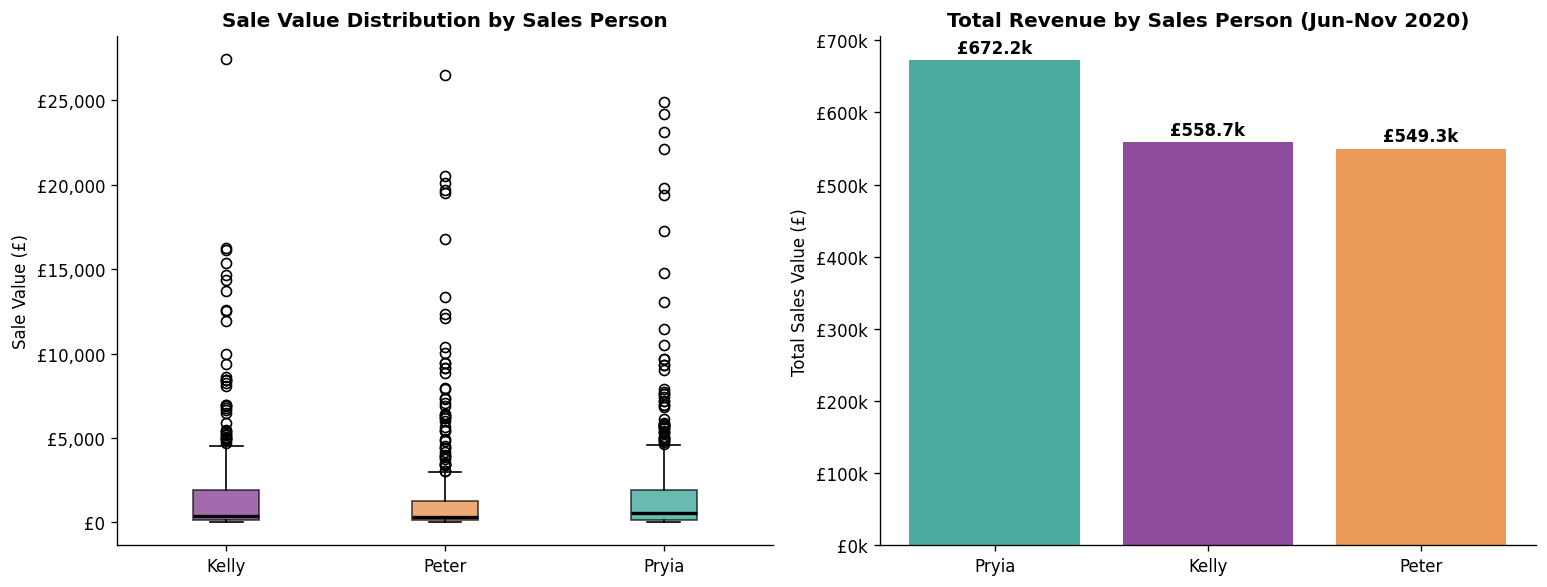

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bp = axes[0].boxplot([kelly.values,peter.values,pryia.values],patch_artist=True,
    labels=['Kelly','Peter','Pryia'],medianprops=dict(color='black',linewidth=2))
for patch,color in zip(bp['boxes'],['#7B2D8B','#E8873A','#2A9D8F']):
    patch.set_facecolor(color);patch.set_alpha(0.7)
axes[0].set_title('Sale Value Distribution by Sales Person',fontweight='bold')
axes[0].set_ylabel('Sale Value (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:,.0f}'))
totals=df_clean.groupby('sales_person')['value_£'].sum().sort_values(ascending=False)
bars=axes[1].bar(totals.index,totals.values,color=[PALETTE[k] for k in totals.index],alpha=0.85)
axes[1].set_title('Total Revenue by Sales Person (Jun-Nov 2020)',fontweight='bold')
axes[1].set_ylabel('Total Sales Value (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x/1000:.0f}k'))
for bar,val in zip(bars,totals.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,val+5000,f'£{val/1000:.1f}k',ha='center',va='bottom',fontweight='bold')
plt.tight_layout()
plt.show();

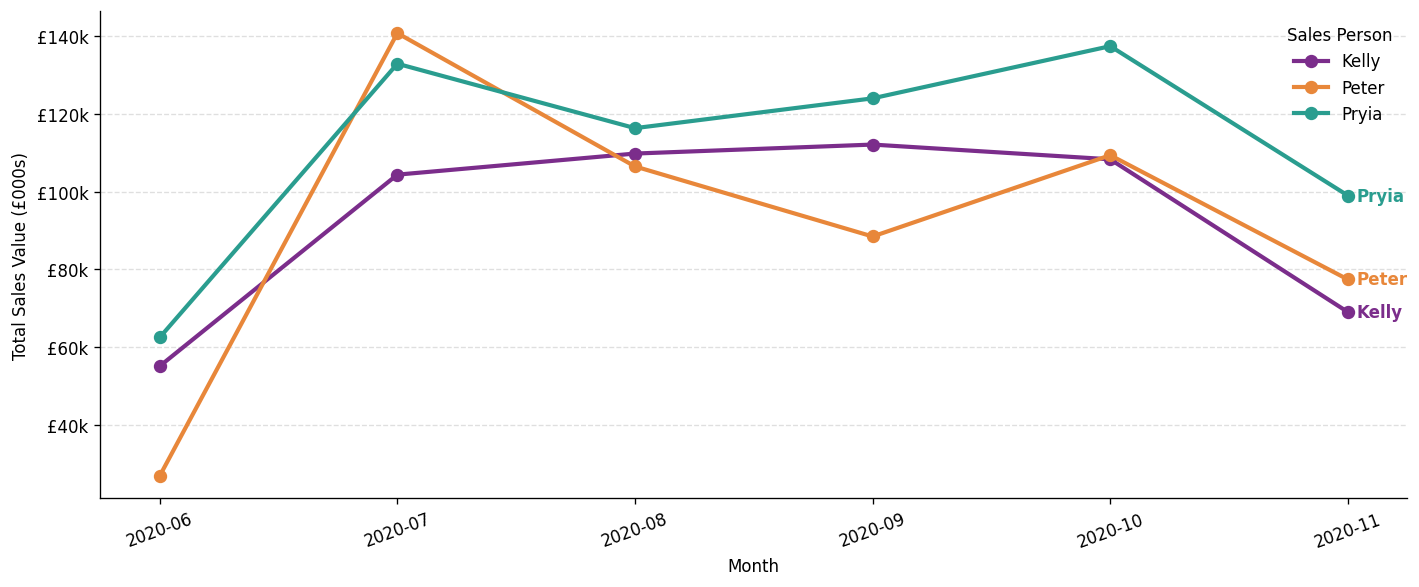

In [35]:
monthly_df=monthly.reset_index()
monthly_df['month_str']=monthly_df['month'].astype(str)
fig,ax=plt.subplots(figsize=(12,5))
for person,color in PALETTE.items():
    ax.plot(monthly_df['month_str'],monthly_df[person]/1000,marker='o',linewidth=2.5,color=color,label=person,markersize=7)
    ax.annotate(person,xy=(monthly_df['month_str'].iloc[-1],monthly_df[person].iloc[-1]/1000),
        xytext=(5,0),textcoords='offset points',color=color,fontweight='bold',va='center')
ax.set_xlabel('Month');ax.set_ylabel('Total Sales Value (£000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:.0f}k'))
ax.legend(title='Sales Person',frameon=False)
ax.grid(axis='y',linestyle='--',alpha=0.4)
plt.xticks(rotation=20);plt.tight_layout()
plt.show();

In [36]:
print(' SALE VALUE BY PRIORITY LEVEL ')
priority_stats=df_clean.groupby('priority')['value_£'].agg(
    Count='count',Mean='mean',Median='median',Std='std').round(2)
print(priority_stats)

print('\n SPEARMAN RANK CORRELATION ')
print('(ordinal priority + non-normal value_£ -> rank-based measure)')
df_pn=df_clean.dropna(subset=['priority_num'])
r_sp,p_sp=stats.spearmanr(df_pn['priority_num'],df_pn['value_£'])
print(f'Spearman r  : {r_sp:.4f}')
print(f'p-value     : {p_sp:.4f}')
print(f'Significant : {"YES" if p_sp<0.05 else "NO - no meaningful correlation"} (alpha=0.05)')
print(f'Note        : r<0.10 is trivially small (Cohen, 1988)')

print('\n KRUSKAL-WALLIS ACROSS PRIORITY GROUPS ')
groups=[g['value_£'].values for _,g in df_clean[df_clean['priority']!='Not Specified'].groupby('priority')]
H_p,p_p=stats.kruskal(*groups)
print(f'H statistic : {H_p:.4f}')
print(f'p-value     : {p_p:.4f}')
print(f'Significant : {"YES" if p_p<0.05 else "NO - no significant difference"} (alpha=0.05)')

 SALE VALUE BY PRIORITY LEVEL 
               Count     Mean  Median      Std
priority                                      
Critical         221  1826.48  435.00  2960.57
High             196  1946.65  496.29  3810.74
Low              200  1462.68  348.37  3124.39
Medium           171  1931.80  566.56  3687.60
Not Specified    213  1747.00  311.04  3704.54

 SPEARMAN RANK CORRELATION 
(ordinal priority + non-normal value_£ -> rank-based measure)
Spearman r  : 0.0634
p-value     : 0.0753
Significant : NO - no meaningful correlation (alpha=0.05)
Note        : r<0.10 is trivially small (Cohen, 1988)

 KRUSKAL-WALLIS ACROSS PRIORITY GROUPS 
H statistic : 5.9460
p-value     : 0.1143
Significant : NO - no significant difference (alpha=0.05)


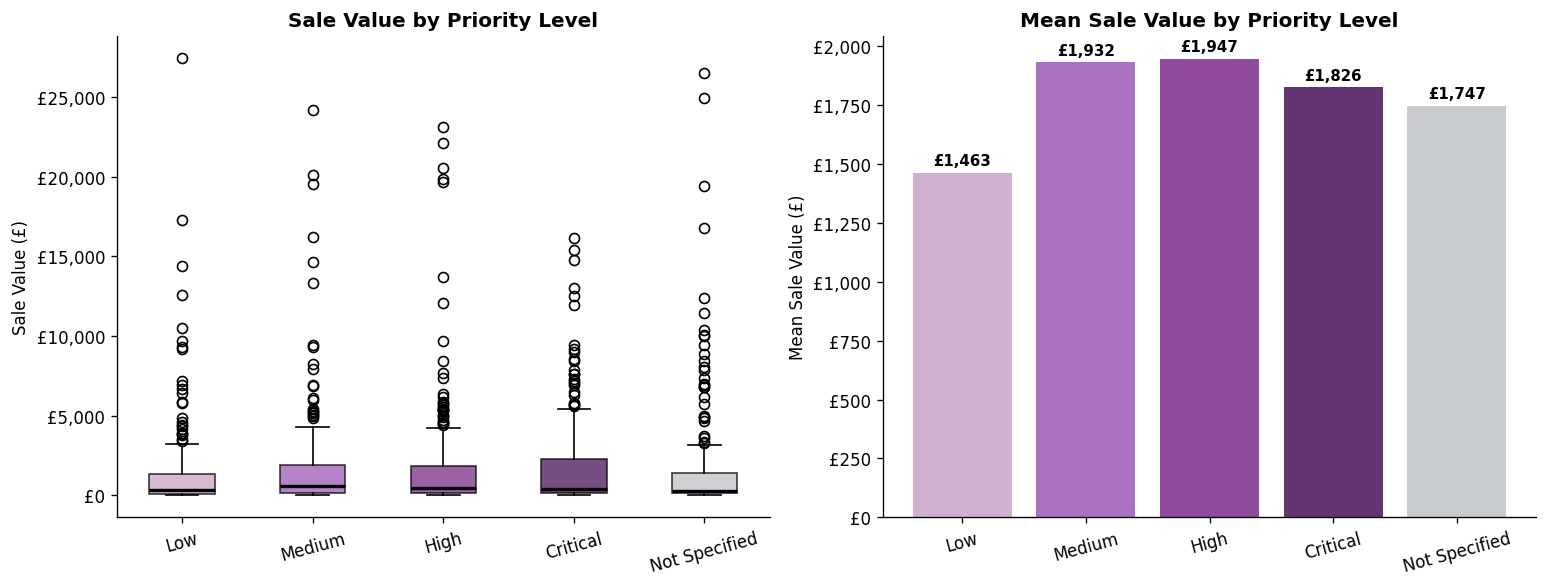

In [37]:
priority_order=['Low','Medium','High','Critical','Not Specified']
priority_colors=['#C8A2C8','#9B59B6','#7B2D8B','#4A1259','#BDC3C7']
fig,axes=plt.subplots(1,2,figsize=(13,5))
bp2=axes[0].boxplot([df_clean[df_clean['priority']==p]['value_£'].values for p in priority_order],
    patch_artist=True,labels=priority_order,medianprops=dict(color='black',linewidth=2))
for patch,color in zip(bp2['boxes'],priority_colors):patch.set_facecolor(color);patch.set_alpha(0.75)
axes[0].set_title('Sale Value by Priority Level',fontweight='bold')
axes[0].set_ylabel('Sale Value (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:,.0f}'))
axes[0].tick_params(axis='x',rotation=15)
means=df_clean.groupby('priority')['value_£'].mean()[priority_order]
bars2=axes[1].bar(priority_order,means.values,color=priority_colors,alpha=0.85)
axes[1].set_title('Mean Sale Value by Priority Level',fontweight='bold')
axes[1].set_ylabel('Mean Sale Value (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:,.0f}'))
axes[1].tick_params(axis='x',rotation=15)
for bar,val in zip(bars2,means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,val+20,f'£{val:,.0f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
plt.tight_layout()
plt.show();

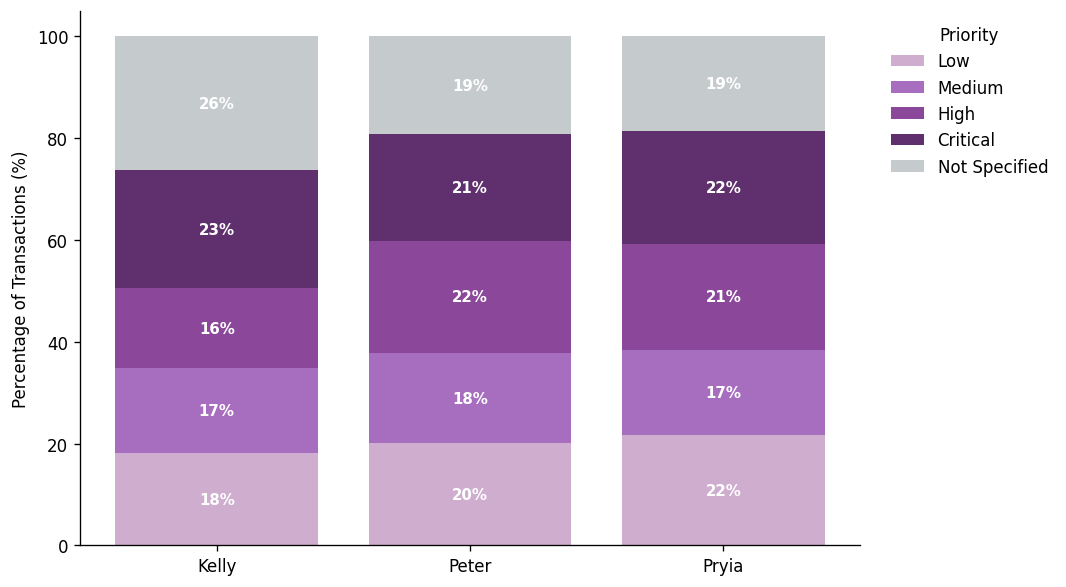

In [38]:
pivot_priority=df_clean.groupby(['sales_person','priority']).size().unstack(fill_value=0)[priority_order]
pct_priority=pivot_priority.div(pivot_priority.sum(axis=1),axis=0)*100
fig,ax=plt.subplots(figsize=(9,5))
bottom=np.zeros(3)
for col,color in zip(priority_order,priority_colors):
    vals=pct_priority[col].values
    ax.bar(pct_priority.index,vals,bottom=bottom,label=col,color=color,alpha=0.88)
    for i,(v,b) in enumerate(zip(vals,bottom)):
        if v>5:ax.text(i,b+v/2,f'{v:.0f}%',ha='center',va='center',fontsize=9,color='white',fontweight='bold')
    bottom+=vals
ax.set_ylabel('Percentage of Transactions (%)')
ax.legend(title='Priority',bbox_to_anchor=(1.02,1),loc='upper left',frameon=False)
plt.tight_layout()
plt.show();

 SPEARMAN CORRELATION MATRIX 
              value_£  log_value  priority_num
value_£        1.0000     1.0000        0.0634
log_value      1.0000     1.0000        0.0634
priority_num   0.0634     0.0634        1.0000


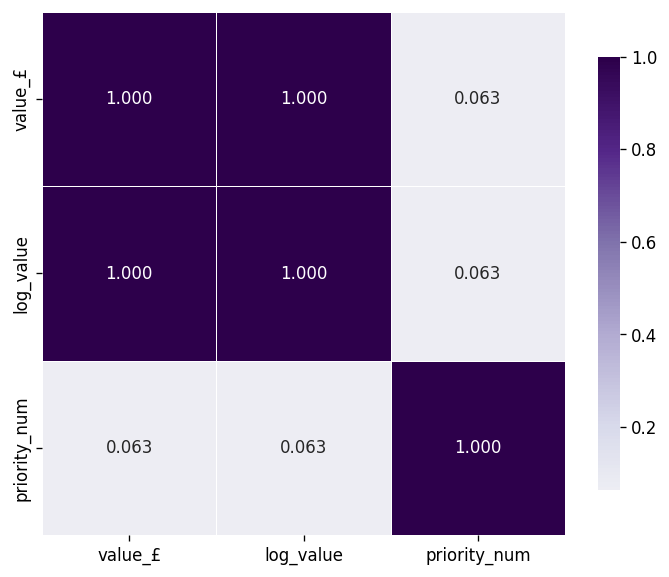

In [39]:
df_corr_all=df_clean[['value_£','log_value','priority_num']].dropna()
corr_matrix=df_corr_all.corr(method='spearman')
print(' SPEARMAN CORRELATION MATRIX ')
print(corr_matrix.round(4))
fig,ax=plt.subplots(figsize=(6,5))
sns.heatmap(corr_matrix,annot=True,fmt='.3f',cmap='PuOr',center=0,
    square=True,linewidths=0.5,ax=ax,cbar_kws={'shrink':0.8})
plt.tight_layout()
plt.show();

 OUTLIER SUMMARY 
Upper fence            : £4,340.73
Total outliers flagged : 122 (12.2%)
Outlier value range    : £4,343.52 – £27,448.24

Outlier count per representative:
sales_person
Pryia    49
Kelly    37
Peter    36
Name: count, dtype: int64


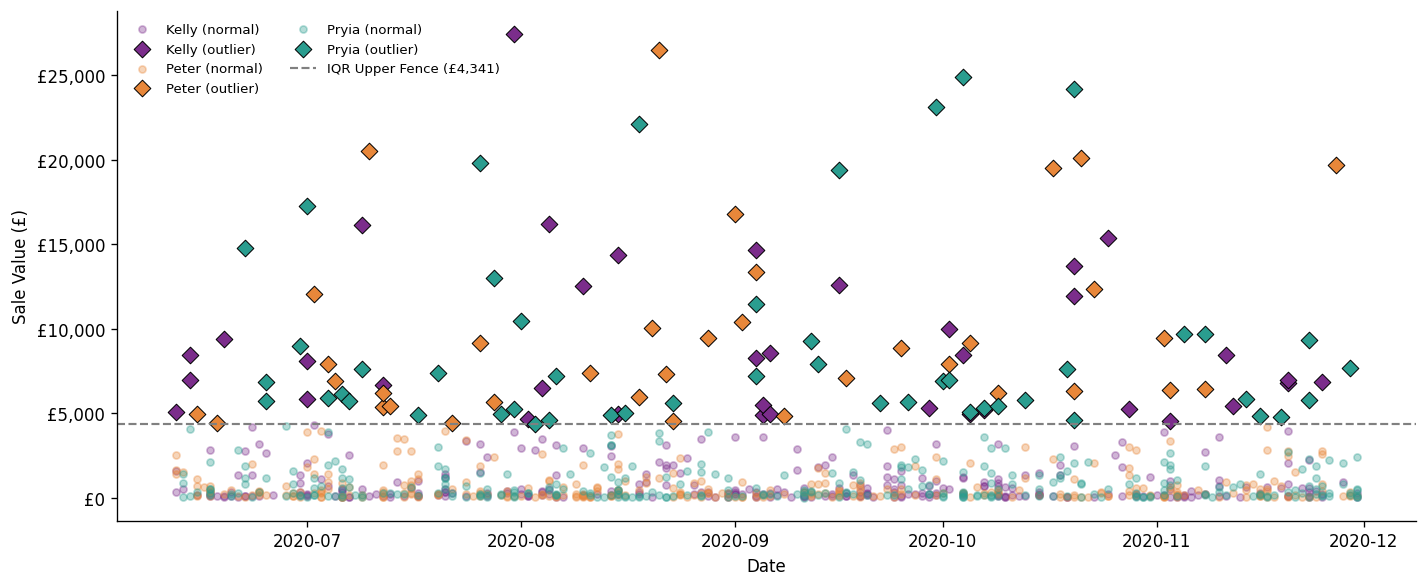

In [40]:
outliers=df_clean[df_clean['outlier_flag']]
print(' OUTLIER SUMMARY ')
print(f'Upper fence            : £{upper_fence:,.2f}')
print(f'Total outliers flagged : {len(outliers)} ({100*len(outliers)/len(df_clean):.1f}%)')
print(f'Outlier value range    : £{outliers["value_£"].min():,.2f} – £{outliers["value_£"].max():,.2f}')
print('\nOutlier count per representative:')
print(outliers['sales_person'].value_counts())
fig,ax=plt.subplots(figsize=(12,5))
for person,color in PALETTE.items():
    sub=df_clean[df_clean['sales_person']==person]
    non_out=sub[~sub['outlier_flag']];out=sub[sub['outlier_flag']]
    ax.scatter(non_out['date'],non_out['value_£'],color=color,alpha=0.35,s=18,label=f'{person} (normal)')
    ax.scatter(out['date'],out['value_£'],color=color,marker='D',s=50,edgecolors='black',linewidth=0.6,label=f'{person} (outlier)')
ax.axhline(upper_fence,color='grey',linestyle='--',linewidth=1.3,label=f'IQR Upper Fence (£{upper_fence:,.0f})')
ax.set_xlabel('Date');ax.set_ylabel('Sale Value (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:,.0f}'))
ax.legend(frameon=False,fontsize=8,ncol=2);plt.tight_layout()
plt.show();